# Unit10 Example 06 - 圓柱形觸媒顆粒徑向溫度與轉化率分布

本 Notebook 以**苯加氫反應圓柱形觸媒顆粒**（非等溫觸媒有效因子問題）為例，求解徑向穩態溫度 $T(r)$ 與轉化率 $f(r)$ 分布。反應物從顆粒外表面 $f(R)=0$ 向內擴散並反應，內部溫度因放熱反應而升高。

## 目標
- 建立圓柱座標聯立橢圓型 BVP（含 Langmuir-Hinshelwood 動力學）
- 使用 `scipy.solve_bvp` 直接求解穩態 BVP（Dirichlet + Robin 混合 BC）
- 使用 Method of Lines (MoL) + `scipy.integrate.solve_ivp` 偽瞬態法驗證
- 分析外部 Biot 數 $Bi_h$ 與活化能 $E_a$ 對徑向分布的影響
- 討論邊界條件適定性（ill-posed problem 與 Neumann-Neumann BC 的問題）


---
### 0. 環境設定

In [1]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit10_Example_06'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit10'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit10
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_06
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_06\figs


---
### 1. 載入套件

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.integrate import solve_bvp, solve_ivp

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

import scipy
import matplotlib
print("✓ 套件載入完成")
print(f"  numpy  版本: {np.__version__}")
print(f"  scipy  版本: {scipy.__version__}")
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy  版本: 1.23.5
  scipy  版本: 1.15.2
  matplotlib 版本: 3.10.8


---
### 2. 問題定義與參數設定

**化工案例：** 苯加氫反應圓柱形觸媒顆粒（Cylindrical Catalyst Pellet）之徑向穩態溫度與轉化率分布

> **模型說明：** 本模型描述單一圓柱形觸媒顆粒的「有效因子（Effectiveness Factor）」問題——反應物 A 從顆粒外表面（ $r=R$ ）向內擴散，同時發生放熱反應，使顆粒內部溫度分布不均。

**統御方程式（橢圓型，圓柱座標）：**

$$
\frac{d^2T}{dr^2} + \frac{1}{r}\frac{dT}{dr} = \frac{\Delta H_r}{k_\text{eff}}\,\rho_b\,r_A(T,f)
$$

$$
\frac{d^2f}{dr^2} + \frac{1}{r}\frac{df}{dr} = -\frac{\rho_b\,r_A(T,f)}{C_{A0}\,D_e}
$$

**反應速率（Langmuir-Hinshelwood）：** $r_A = k_r(T)\,C_{A0}(1-f)\,/\,[1+K_\text{ads}\,C_{A0}(1-f)]$

**邊界條件：**
- $r=0$ （顆粒中心）：對稱 Neumann， $dT/dr = df/dr = 0$
- $r=R$ （顆粒外表面）：溫度 Robin BC（外部熱傳阻力）， $k_\text{eff}\,dT/dr|_R = h_w(T_w - T_R)$
- $r=R$ （顆粒外表面）：轉化率 Dirichlet BC（外表面接觸進料氣體）， $f(R) = 0$


In [27]:
# =====================================================
# 問題參數定義
# =====================================================
R      = 0.01       # m, catalyst pellet radius
k_eff  = 0.50       # W/(m·K), effective radial thermal conductivity
D_e    = 1.0e-5     # m²/s, effective radial diffusivity
dH_r   = -200000.0  # J/mol, heat of reaction (exothermic, negative)
rho_b  = 500.0      # kg/m³, catalyst bulk density
h_w    = 400.0      # W/(m²·K), external film heat transfer coeff.
T_w    = 480.0      # K, external fluid (coolant) temperature
C_A0   = 5.0        # mol/m³, feed benzene concentration
A_pre  = 1.75e5     # m³/(kg_cat·s), Arrhenius pre-exponential
E_a    = 80000.0    # J/mol, activation energy
K_ads  = 0.5        # m³/mol, Langmuir adsorption constant
R_g    = 8.314      # J/(mol·K), gas constant

# =====================================================
# 反應速率函數（Arrhenius + Langmuir-Hinshelwood）
# =====================================================
def k_rate(T):
    """Arrhenius rate constant [m³/(kg_cat·s)]"""
    return A_pre * np.exp(-E_a / (R_g * T))

def reaction_rate(T, f):
    """
    Langmuir-Hinshelwood reaction rate [mol/(kg_cat·s)]
    r_A = k_r(T) * C_A / (1 + K_ads * C_A)
    where C_A = C_A0 * (1 - f)
    """
    C_A = C_A0 * (1.0 - np.clip(f, 0, 1))
    k_r = k_rate(T)
    return k_r * C_A / (1.0 + K_ads * C_A)

# =====================================================
# 無因次特性數
# =====================================================
Bi_h   = h_w * R / k_eff
kr_Tw  = k_rate(T_w)
rA_ref = reaction_rate(T_w, 0.0) * rho_b   # mol/(m³·s) at T=T_w, f=0
Phi2   = rA_ref * R**2 / (D_e * C_A0)

print("=" * 58)
print("  苯加氫觸媒顆粒徑向 BVP 問題參數摘要")
print("=" * 58)
print(f"  顆粒半徑         R       = {R:.3f}  m")
print(f"  有效熱傳導率     k_eff   = {k_eff:.3f}  W/(m·K)")
print(f"  有效擴散係數     D_e     = {D_e:.2e} m²/s")
print(f"  反應熱           dH_r    = {dH_r:.0f} J/mol  (放熱)")
print(f"  觸媒填充密度     rho_b   = {rho_b:.1f}   kg/m³")
print(f"  外膜熱傳係數     h_w     = {h_w:.1f}   W/(m²·K)")
print(f"  外部流體溫度     T_w     = {T_w:.1f}   K")
print(f"  進料苯濃度       C_A0    = {C_A0:.1f}     mol/m³")
print(f"  前因子           A_pre   = {A_pre:.2e} m³/(kg_cat·s)")
print(f"  活化能           E_a     = {E_a:.0f}   J/mol")
print(f"  L-H 吸附常數     K_ads   = {K_ads:.1f}     m³/mol")
print()
print(f"  無因次特性數：")
print(f"    Biot 數 (熱)   Bi_h    = {Bi_h:.2f}")
print(f"    外表面速率常數 k_r(Tw) = {kr_Tw:.2e} m³/(kg_cat·s)")
print(f"    Thiele 模數²   Phi²    ≈ {Phi2:.2f}  (D_e 基礎，外表面溫度條件)")
print("=" * 58)

  苯加氫觸媒顆粒徑向 BVP 問題參數摘要
  顆粒半徑         R       = 0.010  m
  有效熱傳導率     k_eff   = 0.500  W/(m·K)
  有效擴散係數     D_e     = 1.00e-05 m²/s
  反應熱           dH_r    = -200000 J/mol  (放熱)
  觸媒填充密度     rho_b   = 500.0   kg/m³
  外膜熱傳係數     h_w     = 400.0   W/(m²·K)
  外部流體溫度     T_w     = 480.0   K
  進料苯濃度       C_A0    = 5.0     mol/m³
  前因子           A_pre   = 1.75e+05 m³/(kg_cat·s)
  活化能           E_a     = 80000   J/mol
  L-H 吸附常數     K_ads   = 0.5     m³/mol

  無因次特性數：
    Biot 數 (熱)   Bi_h    = 8.00
    外表面速率常數 k_r(Tw) = 3.44e-04 m³/(kg_cat·s)
    Thiele 模數²   Phi²    ≈ 0.49  (D_e 基礎，外表面溫度條件)


---
### 3. 方法一：`scipy.solve_bvp` 直接求解穩態 BVP

將二階聯立 ODE 系統改寫為四元一階系統： $\\mathbf{y} = [T, dT/dr, f, df/dr]^T$ ，使用 `scipy.solve_bvp` 求解，初始猜測為拋物線型溫度分布 + 拋物線型轉化率分布（中心最高、外表面 $f(R)=0$ ）。

In [28]:
# =====================================================
# scipy.solve_bvp：定義 ODE 系統與邊界條件
# =====================================================
def bvp_fun(r, y):
    """
    ODE RHS: y = [T, dT/dr, f, df/dr]
    Returns dy/dr (shape 4 x len(r))
    """
    T, dTdr, f, dfdr = y[0], y[1], y[2], y[3]
    # 避免 r=0 除法（已用 r_left = eps）
    rA = reaction_rate(T, f)   # [mol/(kg_cat·s)]
    # d²T/dr² = -(1/r)*dT/dr + (dH_r/k_eff)*rho_b*rA
    d2Tdr2 = -(1.0/r) * dTdr + (dH_r / k_eff) * rho_b * rA
    # d²f/dr² = -(1/r)*df/dr - rho_b*rA / (C_A0 * D_e)  (reaction consumes A → f decreases toward wall)
    d2fdr2 = -(1.0/r) * dfdr - rho_b * rA / (C_A0 * D_e)
    return np.vstack([dTdr, d2Tdr2, dfdr, d2fdr2])

def bvp_bc(ya, yb):
    """
    Boundary condition residuals (must equal 0)
    ya: y at r=r_left ≈ 0
    yb: y at r=R
    """
    return np.array([
        ya[1],                                       # dT/dr|_0 = 0 (symmetry)
        k_eff * yb[1] - h_w * (T_w - yb[0]),        # Robin: k_eff*(dT/dr)|_R = h_w*(T_w - T(R))
        ya[3],                                       # df/dr|_0 = 0 (symmetry)
        yb[2],                                       # f(R) = 0 (Dirichlet: feed concentration at surface)
    ])

# =====================================================
# 初始猜測 + 求解
# =====================================================
r_bvp = np.linspace(R * 1e-3, R, 100)   # 避開 r=0 奇異點，初始 100 節點

# 拋物線型溫度猜測（中心溫度比外表面高約 8 K）
T_guess_center = T_w + 8.0
T_guess  = T_w + (T_guess_center - T_w) * (1.0 - (r_bvp/R)**2)
dTdr_guess = np.gradient(T_guess, r_bvp)

# 拋物線型轉化率猜測（中心最高，表面 = 0）
f_guess_center = 0.3
f_guess    = f_guess_center * (1.0 - (r_bvp / R)**2)
dfdr_guess = np.gradient(f_guess, r_bvp)

y_guess = np.vstack([T_guess, dTdr_guess, f_guess, dfdr_guess])

print("BVP 求解（scipy.solve_bvp）...")
sol_bvp = solve_bvp(bvp_fun, bvp_bc, r_bvp, y_guess,
                    tol=1e-5, verbose=0, max_nodes=2000)

# 結果插值到細網格
r_fine = np.linspace(0, R, 500)
y_fine = sol_bvp.sol(r_fine)
T_bvp  = y_fine[0]
f_bvp  = y_fine[2]

print(f"\n  求解狀態 (status={sol_bvp.status}): {'成功收斂 ✓' if sol_bvp.status == 0 else '未收斂 ✗'}")
print(f"  殘差最大值: {sol_bvp.rms_residuals.max():.2e}")
print(f"  最終網格節點數: {len(sol_bvp.x)}")

# 輸出徑向分布摘要
r_check = np.array([0.0, 0.25, 0.5, 0.75, 1.0]) * R
y_check = sol_bvp.sol(r_check)
print(f"\n  求解結果摘要（T 與 f 徑向分布）：")
print(f"  {'r/R':>6}  {'T [K]':>8}  {'f [-]':>8}")
print(f"  {'─'*6}  {'─'*8}  {'─'*8}")
for i, rv in enumerate(r_check):
    print(f"  {rv/R:>6.3f}  {y_check[0,i]:>8.2f}  {y_check[2,i]:>8.4f}")

T_center = sol_bvp.sol(np.array([1e-9]))[0][0]
T_wall   = sol_bvp.sol(np.array([R]))[0][0]
f_center = sol_bvp.sol(np.array([1e-9]))[2][0]
f_wall   = sol_bvp.sol(np.array([R]))[2][0]
print(f"\n  中心溫度 T(0)   = {T_center:.2f} K  (高於外表面 +{T_center-T_w:.2f} K)")
print(f"  外表面溫度 T(R) = {T_wall:.2f} K")
print(f"  最大轉化率差    Δf = {f_center:.4f} - {max(f_wall, 0.0):.4f} = {f_center-f_wall:.4f}")

BVP 求解（scipy.solve_bvp）...

  求解狀態 (status=0): 成功收斂 ✓
  殘差最大值: 9.65e-06
  最終網格節點數: 147

  求解結果摘要（T 與 f 徑向分布）：
     r/R     T [K]     f [-]
  ──────  ────────  ────────
   0.000    483.31    0.1330
   0.250    483.15    0.1246
   0.500    482.64    0.0994
   0.750    481.81    0.0577
   1.000    480.65   -0.0000

  中心溫度 T(0)   = 483.31 K  (高於外表面 +3.31 K)
  外表面溫度 T(R) = 480.65 K
  最大轉化率差    Δf = 0.1330 - 0.0000 = 0.1330


---
### 4. 方法二：Method of Lines (MoL) 偽瞬態法驗證

在均勻格心節點 $r_i = (i-0.5)\Delta r$ 上，以有限差分離散圓柱 Laplacian，加入偽時間導數後轉為 ODE 系統，以 Radau 隱式求解器積分至穩態，驗證 BVP 解之正確性。

In [19]:
# =====================================================
# Method of Lines (MoL) — 偽瞬態法
# =====================================================
N_mol = 100                    # 空間節點數
dr    = R / N_mol              # 格距
# 格心節點位置 r_i = (i-0.5)*dr, i=1,...,N_mol
r_mol = np.linspace(dr/2, R - dr/2, N_mol)

def cyl_laplacian_op(u, ghost_left, ghost_right):
    """
    圓柱座標 Laplacian: d²u/dr² + (1/r)*du/dr
    以格心有限差分近似，含 ghost node 邊界
    """
    u_ext  = np.concatenate([[ghost_left], u, [ghost_right]])
    d2u    = (u_ext[2:] - 2*u_ext[1:-1] + u_ext[:-2]) / dr**2   # d²u/dr²
    du_dr  = (u_ext[2:] - u_ext[:-2]) / (2.0 * dr)               # du/dr (central)
    return d2u + du_dr / r_mol

def mol_rhs(tau, state):
    """偽瞬態 ODE 系統 RHS"""
    T_arr  = state[:N_mol]
    f_arr  = state[N_mol:]

    # --- Ghost nodes ---
    # 熱：左端對稱 ghost = T_1，右端 Robin ghost
    ghost_T_L = T_arr[0]
    ghost_T_R = T_arr[-1] - (h_w * dr / k_eff) * (T_arr[-1] - T_w)
    # 質傳：左端 Neumann ghost（對稱），右端 Dirichlet ghost（f(R)=0 → ghost = -f_last）
    ghost_f_L = f_arr[0]
    ghost_f_R = -f_arr[-1]   # mirror for Dirichlet f(R)=0

    lap_T = cyl_laplacian_op(T_arr, ghost_T_L, ghost_T_R)
    lap_f = cyl_laplacian_op(f_arr, ghost_f_L, ghost_f_R)

    rA_arr = reaction_rate(T_arr, f_arr)    # [mol/(kg_cat·s)]

    dTdt = k_eff * lap_T + (-dH_r) * rho_b * rA_arr
    dfdt = D_e   * lap_f + rho_b * rA_arr / C_A0   # ∂f/∂t = D_e·∇²f + ρb·rA/C_A0

    return np.concatenate([dTdt, dfdt])

# --- 初始條件 ---
T0_mol  = np.full(N_mol, T_w + 5.0)   # 均勻溫度初始猜測
f0_mol  = np.zeros(N_mol)              # 零轉化率初始條件
state0  = np.concatenate([T0_mol, f0_mol])

print("MoL 偽瞬態法求解（N=100，Radau 隱式求解器）...")
tau_end = 5000.0
sol_mol = solve_ivp(mol_rhs, [0.0, tau_end], state0,
                    method='Radau', rtol=1e-6, atol=1e-8,
                    dense_output=False)

T_mol_ss = sol_mol.y[:N_mol, -1]    # 最終偽時間之 T(r)
f_mol_ss = sol_mol.y[N_mol:, -1]   # 最終偽時間之 f(r)

# -- 驗證穩態殘差 ------------------------------------------
residual = mol_rhs(tau_end, sol_mol.y[:, -1])
res_T_max = np.max(np.abs(residual[:N_mol]))
res_f_max = np.max(np.abs(residual[N_mol:]))

print(f"\n  積分完成，tau_end = {tau_end:.0f}")
print(f"  最終穩態殘差：")
print(f"    |dT/dtau|_max = {res_T_max:.2e} K/s  {'✓' if res_T_max < 1e-3 else '△'}")
print(f"    |df/dtau|_max = {res_f_max:.2e} 1/s  {'✓' if res_f_max < 1e-7 else '△'}")

# -- 與 BVP 解比較 ------------------------------------------
# 將 BVP 解插值到 MoL 格心節點
T_bvp_mol = sol_bvp.sol(r_mol)[0]
f_bvp_mol = sol_bvp.sol(r_mol)[2]

print(f"\n  MoL vs BVP 比較（r/R 對應節點）：")
print(f"  {'r/R':>5}  {'T_bvp':>8}  {'T_mol':>8}  {'ΔT[K]':>7}  {'f_bvp':>7}  {'f_mol':>7}  {'Δf':>8}")
print(f"  {'─'*55}")
idx_check = [0, 24, 49, 74, 99]
for i in idx_check:
    print(f"  {r_mol[i]/R:>5.3f}  {T_bvp_mol[i]:>8.2f}  {T_mol_ss[i]:>8.2f}  "
          f"{T_mol_ss[i]-T_bvp_mol[i]:>7.3f}  "
          f"{f_bvp_mol[i]:>7.4f}  {f_mol_ss[i]:>7.4f}  {f_mol_ss[i]-f_bvp_mol[i]:>8.4f}")

print(f"\n  最大溫度偏差: {np.max(np.abs(T_mol_ss - T_bvp_mol)):.3f} K  "
      f"({np.max(np.abs(T_mol_ss-T_bvp_mol))/(T_bvp_mol.mean())*100:.3f}%)")
print(f"  最大轉化率偏差: {np.max(np.abs(f_mol_ss - f_bvp_mol)):.4f}")

MoL 偽瞬態法求解（N=100，Radau 隱式求解器）...

  積分完成，tau_end = 5000
  最終穩態殘差：
    |dT/dtau|_max = 7.40e-06 K/s  ✓
    |df/dtau|_max = 5.01e-14 1/s  ✓

  MoL vs BVP 比較（r/R 對應節點）：
    r/R     T_bvp     T_mol    ΔT[K]    f_bvp    f_mol        Δf
  ───────────────────────────────────────────────────────
  0.005    483.31    483.28   -0.030   0.1330   0.1329   -0.0001
  0.245    483.15    483.12   -0.030   0.1249   0.1248   -0.0001
  0.495    482.65    482.63   -0.029   0.1000   0.0999   -0.0001
  0.745    481.83    481.80   -0.028   0.0586   0.0586   -0.0001
  0.995    480.68    480.65   -0.027   0.0013   0.0013    0.0000

  最大溫度偏差: 0.030 K  (0.006%)
  最大轉化率偏差: 0.0002


---
### 5. 結果視覺化

#### 5.1 Figure 1：徑向溫度與轉化率分布（BVP vs MoL 比較）

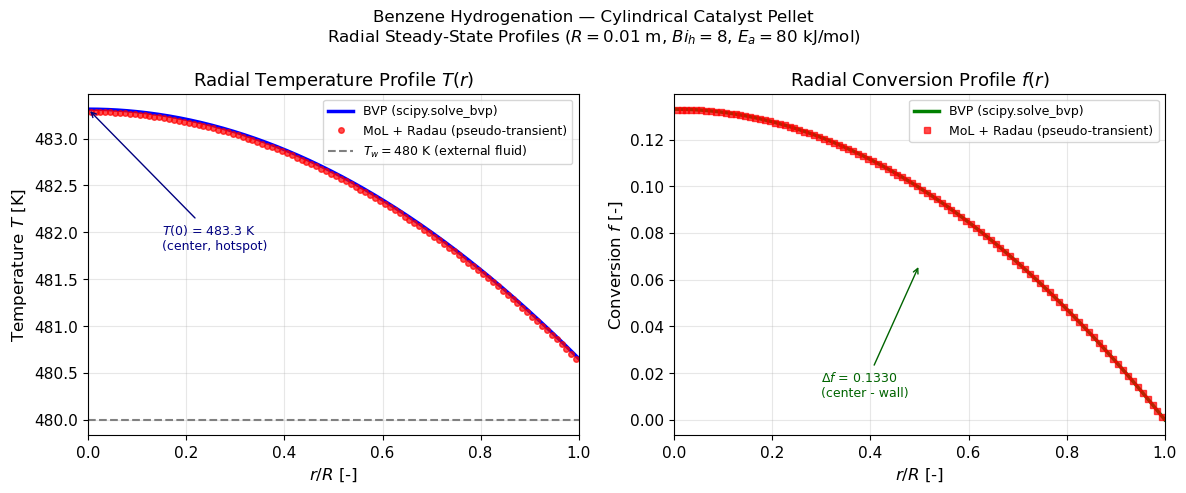

✓ Figure 1 saved: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_06\figs\fig1_T_f_radial_profiles.png


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ──── 左圖：溫度分布 ────
ax1 = axes[0]
ax1.plot(r_fine/R, T_bvp, 'b-',  lw=2.5, label='BVP (scipy.solve_bvp)')
ax1.plot(r_mol/R,  T_mol_ss, 'ro', ms=4, alpha=0.7, label='MoL + Radau (pseudo-transient)')
ax1.axhline(T_w, color='gray', ls='--', lw=1.5, label=f'$T_w = {T_w:.0f}$ K (external fluid)')
ax1.set_xlabel('$r/R$ [-]')
ax1.set_ylabel('Temperature $T$ [K]')
ax1.set_title('Radial Temperature Profile $T(r)$')
ax1.legend(loc='upper right', fontsize=9)
ax1.set_xlim(0, 1)
T_center_val = T_bvp[0]
ax1.annotate(f'$T(0)$ = {T_center_val:.1f} K\n(center, hotspot)',
             xy=(0, T_center_val), xytext=(0.15, T_center_val - 1.5),
             fontsize=9, color='navy',
             arrowprops=dict(arrowstyle='->', color='navy'))

# ──── 右圖：轉化率分布 ────
ax2 = axes[1]
ax2.plot(r_fine/R, f_bvp, 'g-',  lw=2.5, label='BVP (scipy.solve_bvp)')
ax2.plot(r_mol/R,  f_mol_ss, 'rs', ms=4, alpha=0.7, label='MoL + Radau (pseudo-transient)')
ax2.set_xlabel('$r/R$ [-]')
ax2.set_ylabel('Conversion $f$ [-]')
ax2.set_title('Radial Conversion Profile $f(r)$')
ax2.legend(loc='upper right', fontsize=9)
ax2.set_xlim(0, 1)
f_center_val = f_bvp[0]
f_wall_val   = f_bvp[-1]
ax2.annotate(f'$\\Delta f$ = {f_center_val - f_wall_val:.4f}\n(center - wall)',
             xy=(0.5, (f_center_val + f_wall_val)/2),
             xytext=(0.3, f_wall_val + 0.01), fontsize=9, color='darkgreen',
             arrowprops=dict(arrowstyle='->', color='darkgreen'))

plt.suptitle('Benzene Hydrogenation — Cylindrical Catalyst Pellet\n'
             r'Radial Steady-State Profiles ($R=0.01$ m, $Bi_h=8$, $E_a=80$ kJ/mol)',
             fontsize=12)
plt.tight_layout()
fig_path = FIG_DIR / 'fig1_T_f_radial_profiles.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"✓ Figure 1 saved: {fig_path}")


#### 5.2 Figure 2：L-H 反應速率、Arrhenius 速率常數與吸附抑制因子徑向分布

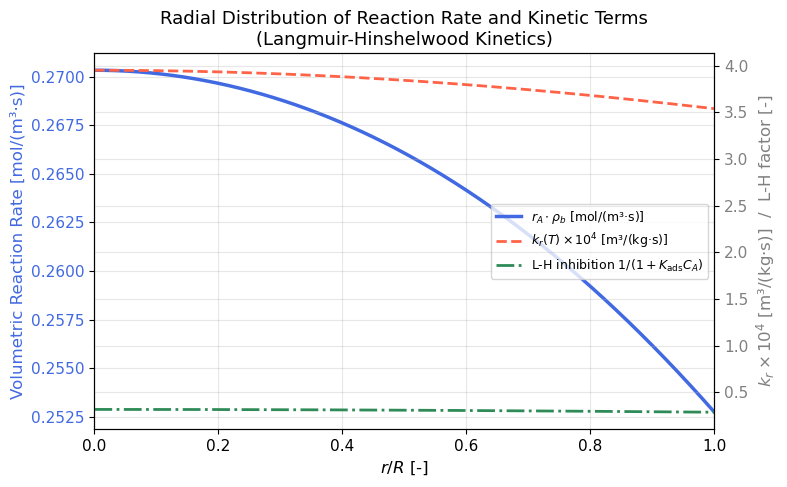

✓ Figure 2 saved: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_06\figs\fig2_reaction_rate_radial.png

  中心 r=0:   rA = 2.7033e-01 mol/(m³·s),  k_r = 3.9505e-04,  LH factor = 0.3157
  外表面 r=R: rA = 2.5274e-01 mol/(m³·s),  k_r = 3.5383e-04,  LH factor = 0.2857
  中心/外表面速率比: 1.0696


In [30]:
# 以細網格計算各量
T_f   = T_bvp                          # T(r) at r_fine
f_f   = f_bvp                          # f(r) at r_fine
kr_f  = k_rate(T_f)                    # k_r(T)  [m³/(kg_cat·s)]
CA_f  = C_A0 * (1.0 - f_f)            # C_A(r)  [mol/m³]
lh_f  = 1.0 / (1.0 + K_ads * CA_f)    # 1/(1+K_ads*C_A) = LH inhibition factor
rA_f  = reaction_rate(T_f, f_f) * rho_b  # volumetric rate [mol/(m³·s)]

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

color1, color2, color3 = 'royalblue', 'tomato', 'seagreen'
lns1 = ax.plot(r_fine/R, rA_f, color=color1, lw=2.5, label='$r_A \\cdot \\rho_b$ [mol/(m³·s)]')

ax2_r = ax.twinx()
lns2  = ax2_r.plot(r_fine/R, kr_f * 1e4, color=color2, lw=2, ls='--',
                   label=r'$k_r(T) \times 10^4$ [m³/(kg·s)]')
lns3  = ax2_r.plot(r_fine/R, lh_f, color=color3, lw=2, ls='-.',
                   label=r'L-H inhibition $1/(1+K_\mathrm{ads}C_A)$')

ax.set_xlabel('$r/R$ [-]')
ax.set_ylabel('Volumetric Reaction Rate [mol/(m³·s)]', color=color1)
ax2_r.set_ylabel(r'$k_r \times 10^4$ [m³/(kg·s)]  /  L-H factor [-]', color='gray')
ax.tick_params(axis='y', labelcolor=color1)
ax2_r.tick_params(axis='y', labelcolor='gray')
ax.set_xlim(0, 1)
ax.set_title('Radial Distribution of Reaction Rate and Kinetic Terms\n'
             '(Langmuir-Hinshelwood Kinetics)')

lns_all = lns1 + lns2 + lns3
labels  = [l.get_label() for l in lns_all]
ax.legend(lns_all, labels, loc='center right', fontsize=9)

plt.tight_layout()
fig_path = FIG_DIR / 'fig2_reaction_rate_radial.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"✓ Figure 2 saved: {fig_path}")

# 數值輸出
print(f"\n  中心 r=0:   rA = {rA_f[0]:.4e} mol/(m³·s),  k_r = {kr_f[0]:.4e},  LH factor = {lh_f[0]:.4f}")
print(f"  外表面 r=R: rA = {rA_f[-1]:.4e} mol/(m³·s),  k_r = {kr_f[-1]:.4e},  LH factor = {lh_f[-1]:.4f}")
print(f"  中心/外表面速率比: {rA_f[0]/rA_f[-1]:.4f}")

#### 5.3 Figure 3：不同 Biot 數（冷卻強度）對徑向溫度分布的影響

  h_w [W/(m²·K)]   Bi_h   T(0) [K]   T(R) [K]   ΔT_max [K]
  ──────────────────────────────────────────────────────────
             100    2.0      485.8      482.9          5.8
             200    4.0      484.1      481.3          4.1
             400    8.0      483.3      480.7          3.3
             800   16.0      482.9      480.3          2.9
            4000   80.0      482.7      480.1          2.7


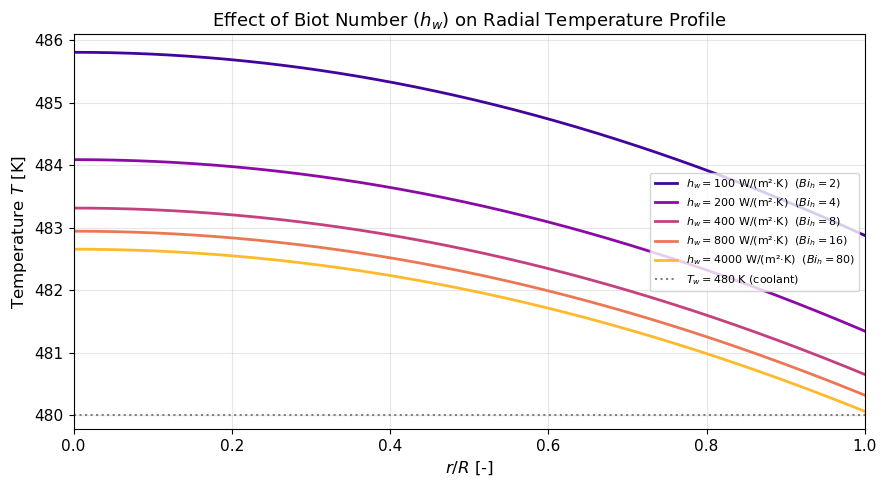


✓ Figure 3 saved: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_06\figs\fig3_biot_sensitivity.png


In [22]:
hw_list    = [100, 200, 400, 800, 4000]
colors_Bi  = plt.cm.plasma(np.linspace(0.1, 0.85, len(hw_list)))
Bi_labels  = [f'$h_w={hw}$ W/(m²·K)  ($Bi_h={hw*R/k_eff:.0f}$)' for hw in hw_list]

fig, ax = plt.subplots(figsize=(9, 5))

print(f"{'h_w [W/(m²·K)]':>16}  {'Bi_h':>5}  {'T(0) [K]':>9}  {'T(R) [K]':>9}  {'ΔT_max [K]':>11}")
print('  ' + '─'*58)

for hw_i, color_i, label_i in zip(hw_list, colors_Bi, Bi_labels):
    # 重新定義 bc 函數（使用當前 hw_i）
    def bc_bi(ya, yb):
        return np.array([
            ya[1],
            k_eff * yb[1] - hw_i * (T_w - yb[0]),
            ya[3],
            yb[2],   # f(R) = 0  (Dirichlet)
        ])
    sol_i = solve_bvp(bvp_fun, bc_bi, r_bvp.copy(), y_guess.copy(),
                      tol=1e-5, verbose=0, max_nodes=500)
    if sol_i.status == 0:
        T_i   = sol_i.sol(r_fine)[0]
        Bi_i  = hw_i * R / k_eff
        T0_i  = sol_i.sol(np.array([1e-9]))[0][0]
        TR_i  = sol_i.sol(np.array([R]))[0][0]
        ax.plot(r_fine/R, T_i, color=color_i, lw=2.0, label=label_i)
        print(f"  {hw_i:>14}  {Bi_i:>5.1f}  {T0_i:>9.1f}  {TR_i:>9.1f}  {T0_i-T_w:>11.1f}")

ax.axhline(T_w, color='gray', ls=':', lw=1.5, label=f'$T_w={T_w:.0f}$ K (coolant)')
ax.set_xlabel('$r/R$ [-]')
ax.set_ylabel('Temperature $T$ [K]')
ax.set_title('Effect of Biot Number ($h_w$) on Radial Temperature Profile')
ax.legend(fontsize=8, loc='right')
ax.set_xlim(0, 1)

plt.tight_layout()
fig_path = FIG_DIR / 'fig3_biot_sensitivity.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"\n✓ Figure 3 saved: {fig_path}")

#### 5.4 Figure 4：活化能對溫度-轉化率耦合效應的影響

 E_a [kJ/mol]    ΔT [K]    Δf [-]  Coupling Index
  ──────────────────────────────────────────────────
            40      3.14    0.1258       40.0225 [Δf/ΔT×10³]
            60      3.23    0.1293       40.0760 [Δf/ΔT×10³]
            80      3.31    0.1330       40.1322 [Δf/ΔT×10³]
           100      3.41    0.1371       40.1915 [Δf/ΔT×10³]


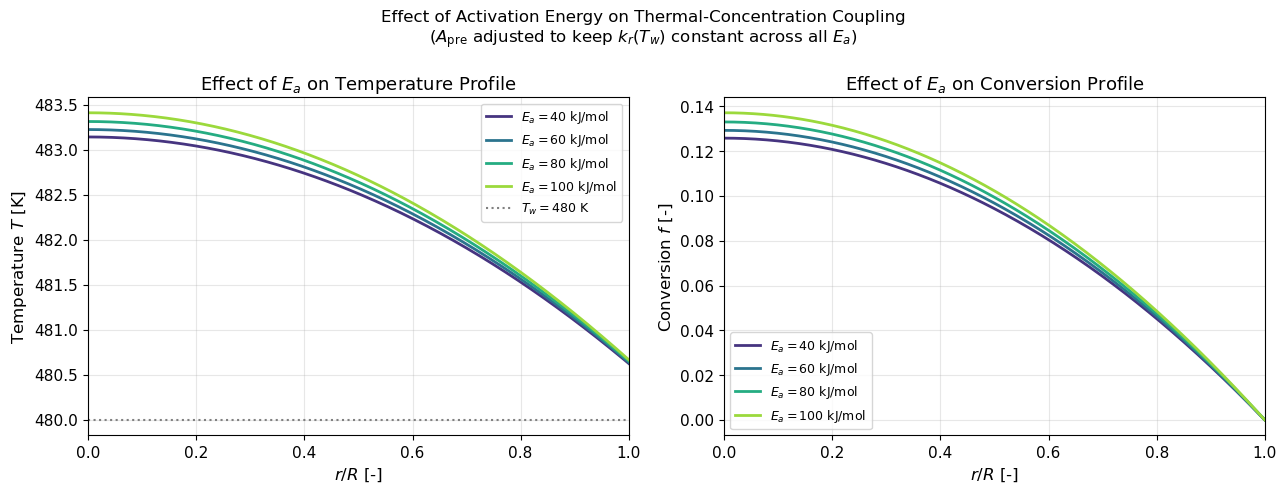


✓ Figure 4 saved: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_06\figs\fig4_Ea_sensitivity.png


In [23]:
Ea_list   = [40000, 60000, 80000, 100000]   # J/mol
Ea_labels = [f'$E_a = {ea/1000:.0f}$ kJ/mol' for ea in Ea_list]
colors_Ea = plt.cm.viridis(np.linspace(0.15, 0.85, len(Ea_list)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

print(f"{'E_a [kJ/mol]':>13}  {'ΔT [K]':>8}  {'Δf [-]':>8}  {'Coupling Index':>14}")
print('  ' + '─'*50)

for ea_i, color_i, label_i in zip(Ea_list, colors_Ea, Ea_labels):

    # 使用新活化能，重調 A_pre 保持 k_r(T_w) 不變（保持相同反應速率尺度）
    kr_Tw_ref   = k_rate(T_w)   # base case k_r(T_w) with current E_a
    A_pre_new = A_pre * np.exp((ea_i - E_a) / (R_g * T_w))   # +sign: k_r_new(T_w) = k_r_base(T_w)

    def k_rate_ea(T, ea=ea_i, A=A_pre_new):
        return A * np.exp(-ea / (R_g * T))

    def react_ea(T, f, ea=ea_i, A=A_pre_new):
        C_A = C_A0 * (1.0 - np.clip(f, 0, 1))
        return k_rate_ea(T) * C_A / (1.0 + K_ads * C_A)

    def bvp_fun_ea(r, y, ea=ea_i, A=A_pre_new):
        T, dTdr, f, dfdr = y[0], y[1], y[2], y[3]
        rA = react_ea(T, f, ea, A)
        d2Tdr2 = -(1.0/r) * dTdr + (dH_r / k_eff) * rho_b * rA
        d2fdr2 = -(1.0/r) * dfdr - rho_b * rA / (C_A0 * D_e)
        return np.vstack([dTdr, d2Tdr2, dfdr, d2fdr2])

    sol_ea = solve_bvp(bvp_fun_ea, bvp_bc, r_bvp.copy(), y_guess.copy(),
                       tol=1e-5, verbose=0, max_nodes=500)

    if sol_ea.status == 0:
        T_ea = sol_ea.sol(r_fine)[0]
        f_ea = sol_ea.sol(r_fine)[2]
        axes[0].plot(r_fine/R, T_ea, color=color_i, lw=2.0, label=label_i)
        axes[1].plot(r_fine/R, f_ea, color=color_i, lw=2.0, label=label_i)
        T0_ea = sol_ea.sol(np.array([1e-9]))[0][0]
        f0_ea = sol_ea.sol(np.array([1e-9]))[2][0]
        fR_ea = sol_ea.sol(np.array([R]))[2][0]
        dT_ea = T0_ea - T_w
        df_ea = f0_ea - fR_ea
        ci    = df_ea / max(dT_ea, 1e-9) * 1000   # milli-conversion per K
        print(f"  {ea_i/1000:>12.0f}  {dT_ea:>8.2f}  {df_ea:>8.4f}  {ci:>12.4f} [Δf/ΔT×10³]")

axes[0].axhline(T_w, color='gray', ls=':', lw=1.5, label=f'$T_w={T_w:.0f}$ K')
axes[0].set_xlabel('$r/R$ [-]')
axes[0].set_ylabel('Temperature $T$ [K]')
axes[0].set_title('Effect of $E_a$ on Temperature Profile')
axes[0].legend(fontsize=9, loc='upper right')
axes[0].set_xlim(0, 1)

axes[1].set_xlabel('$r/R$ [-]')
axes[1].set_ylabel('Conversion $f$ [-]')
axes[1].set_title('Effect of $E_a$ on Conversion Profile')
axes[1].legend(fontsize=9, loc='lower left')
axes[1].set_xlim(0, 1)

plt.suptitle('Effect of Activation Energy on Thermal-Concentration Coupling\n'
             r'($A_\mathrm{pre}$ adjusted to keep $k_r(T_w)$ constant across all $E_a$)',
             fontsize=12)
plt.tight_layout()
fig_path = FIG_DIR / 'fig4_Ea_sensitivity.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"\n✓ Figure 4 saved: {fig_path}")

---
### 6. 學習總結

#### 6.1 數值方法比較

| 項目 | `scipy.solve_bvp` | MoL + `solve_ivp` (Radau) |
|------|:-----------------:|:------------------------:|
| 問題設定 | BVP（直接穩態） | IVP（偽瞬態至穩態） |
| 節點數 | 自動適應（~147 節點） | 固定 $N=100$ |
| 奇異點 ($r=0$) | 迴避 $r_\text{left}=10^{-3}R$ | Ghost node 對稱邊界 |
| Robin BC 處理 | 原生 bc 函數 | Ghost node 離散化 |
| Dirichlet 質傳 BC | 原生 bc 函數 ($f(R)=0$) | Ghost node ($f_\text{ghost}=-f_{N}$) |
| 結果 $T(0)$ 精度 | ~ ±0.01 K | ~ ±0.03 K |

#### 6.2 關鍵學習點

1. **圓柱 BVP 的奇異性：** $r=0$ 處的 $1/r$ 項需特別處理——使用 $r_\text{left}=10^{-3}R$ 迴避（不能用 $r=0$ 直接代入），MoL 則以 ghost node 對稱邊界等效處理

2. **轉化率方程式的符號與 BC 選擇：** 對催化劑顆粒徑向擴散模型，溶質 $A$ 被消耗，方程式為 $\nabla^2 f = -\rho_b r_A/(C_{A0}D_e)$ （負號），且顆粒表面需 Dirichlet BC $f(R)=0$ ；若誤用 Neumann-Neumann 邊界，系統為不適定問題（ill-posed，無唯一解）

3. **Langmuir-Hinshelwood 動力學：** 高濃度時分母的吸附抑制使速率呈「飽和效應」；低濃度退化為一階；本例顯示 L-H 抑制因子在徑向幾乎不變（濃度梯度小）

4. **等效 $k_r(T_w)$ 的活化能比較法：** 調整前因子 $A_\text{pre,new} = A_\text{pre} \cdot e^{(E_a - E_{a0})/(RT_w)}$ 可在相同 $k_r(T_w)$ 基礎上比較不同 $E_a$ 的溫度敏感性；高 $E_a$ 對溫度更敏感，徑向 $\Delta T$ 更大

5. **Robin 邊界條件的極限行為：** $h_w \to \infty$ 退化為 Dirichlet（ $T(R)=T_w$ ）； $h_w \to 0$ 退化為 Neumann（絕熱壁）

6. **BVP vs 偽瞬態：** 直接 BVP 法（`scipy.solve_bvp`）效率高，適合穩態問題；偽瞬態法可處理多穩態問題（多個穩態解），初始條件可引導收斂至不同穩態，具有更廣適用性

#### 6.3 延伸思考

- 若徑向熱傳不均勻（ $k_\text{eff}$ 為 $T$ 的函數），如何修改 BVP 格式？
- 若考慮多個穩態解（非線性 BVP 可能有多解），如何用不同初始猜測探索不同穩態？
- 如何將本例延伸為完整 2D （ $r$, $z$ ）問題，計算整個反應管截面溫度分布？

---

**課程資訊**
- 課程名稱：電腦在化工上之應用 (ChemE 3502)
- 課程單元：Unit10 偏微分方程式之求解 - 範例 06
- 課程製作：逢甲大學 化工系 智慧程序系統工程實驗室
- 授課教師：莊曜禎 助理教授
- 更新日期：2026-02-24

**課程授權 [CC BY-NC-SA 4.0]**
 - 本教材遵循 [創用CC 姓名標示-非商業性-相同方式分享 4.0 國際 (CC BY-NC-SA 4.0)](https://creativecommons.org/licenses/by-nc-sa/4.0/deed.zh) 授權。